In [8]:
from google.colab import files
uploaded = files.upload()

Saving MTA_Subway_Customer_Journey-Focused_Metrics__Beginning_2025.csv to MTA_Subway_Customer_Journey-Focused_Metrics__Beginning_2025.csv


In [10]:
import pandas as pd
df = pd.read_csv("MTA_Subway_Customer_Journey-Focused_Metrics__Beginning_2025.csv")
df.head()

,month,division,line,period,num_passengers,additional platform time,additional train time,total_apt,total_att,over_five_mins,over_five_mins_perc,customer journey time performance
0,2025-01-01,A DIVISION,1,offpeak,6.180143e+06,0.741047,0.532418,4.579779e+06,3.290418e+06,671979.372650,0.108732,0.891268
1,2025-01-01,A DIVISION,1,peak,6.405407e+06,0.718459,0.540068,4.602025e+06,3.459355e+06,492888.737915,0.076949,0.923051
2,2025-01-01,A DIVISION,2,offpeak,3.609504e+06,1.306796,0.550317,4.716885e+06,1.986369e+06,576156.240662,0.159622,0.840378
3,2025-01-01,A DIVISION,2,peak,4.147635e+06,1.147946,0.570769,4.761259e+06,2.367343e+06,591446.958496,0.142599,0.857401
4,2025-01-01,A DIVISION,3,offpeak,2.910441e+06,0.870717,0.437349,2.534170e+06,1.272880e+06,334059.471680,0.114780,0.885220


Shape: (528, 12)

Missing Values:
month                                0
division                             0
line                                 0
period                               0
num_passengers                       0
additional platform time             0
additional train time                0
total_apt                            0
total_att                            0
over_five_mins                       0
over_five_mins_perc                  0
customer journey time performance    0
dtype: int64


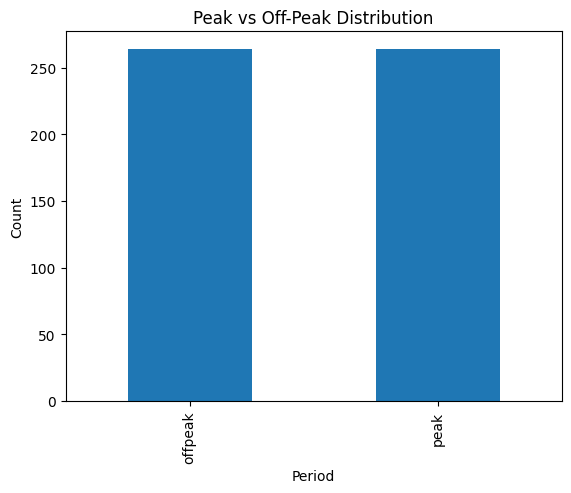

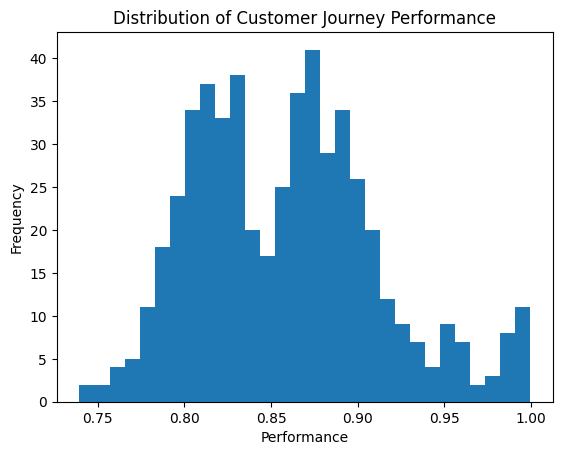

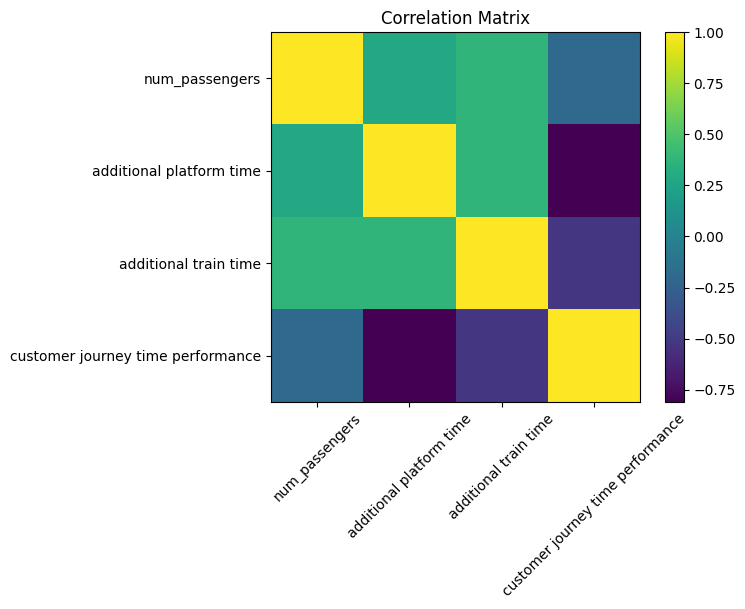


Correlation Matrix:
                                    num_passengers  additional platform time  \
num_passengers                           1.000000                  0.279693   
additional platform time                 0.279693                  1.000000   
additional train time                    0.371962                  0.371947   
customer journey time performance       -0.191375                 -0.809531   

                                   additional train time  \
num_passengers                                  0.371962   
additional platform time                        0.371947   
additional train time                           1.000000   
customer journey time performance              -0.522048   

                                   customer journey time performance  
num_passengers                                             -0.191375  
additional platform time                                   -0.809531  
additional train time                                      -0.522048

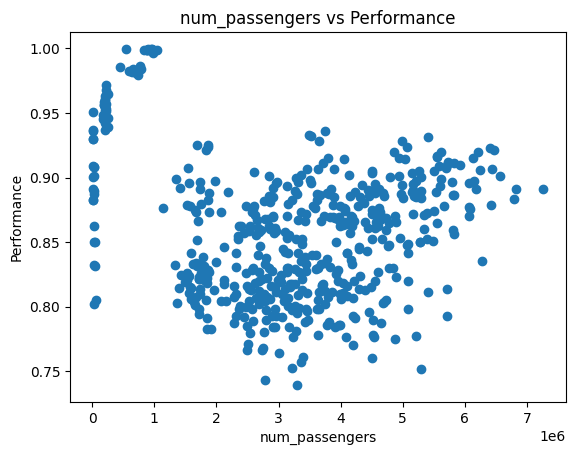

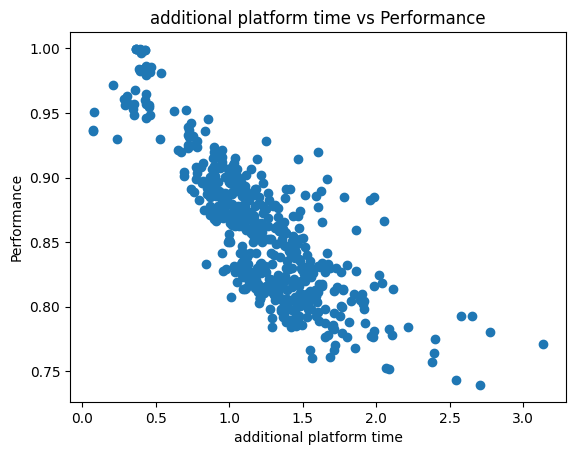

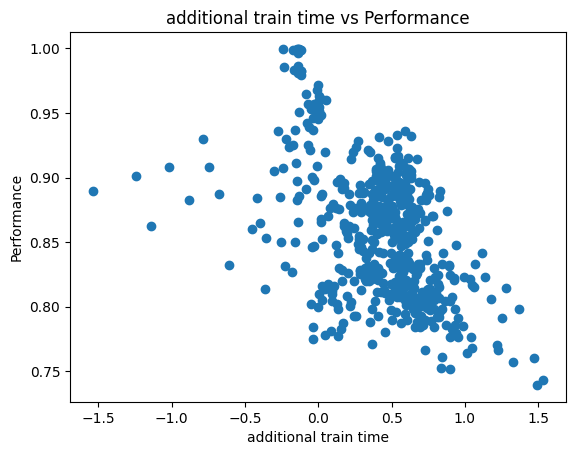

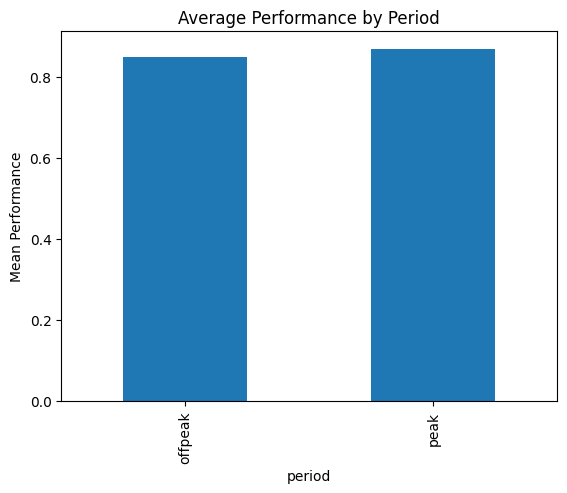


Mean by Period:
 period
offpeak    0.849322
peak       0.868550
Name: customer journey time performance, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# 1. Basic Info
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# 2. Period Distribution
plt.figure()
df['period'].value_counts().plot(kind='bar')
plt.title("Peak vs Off-Peak Distribution")
plt.xlabel("Period")
plt.ylabel("Count")
plt.show()

# 3. Histogram of Target
plt.figure()
plt.hist(df['customer journey time performance'], bins=30)
plt.title("Distribution of Customer Journey Performance")
plt.xlabel("Performance")
plt.ylabel("Frequency")
plt.show()

# 4. Correlation Matrix
corr = df[['num_passengers',
           'additional platform time',
           'additional train time',
           'customer journey time performance']].corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Matrix:\n", corr)

# 5. Scatter Plots (Key Relationships)
features = ['num_passengers',
            'additional platform time',
            'additional train time']

target = 'customer journey time performance'

for col in features:
    plt.figure()
    plt.scatter(df[col], df[target])
    plt.title(f"{col} vs Performance")
    plt.xlabel(col)
    plt.ylabel("Performance")
    plt.show()

# 6. Peak vs Offpeak Comparison
grouped = df.groupby('period')[target].mean()

plt.figure()
grouped.plot(kind='bar')
plt.title("Average Performance by Period")
plt.ylabel("Mean Performance")
plt.show()

print("\nMean by Period:\n", grouped)

In [12]:
import pandas as pd
df.head()

,month,division,line,period,num_passengers,additional platform time,additional train time,total_apt,total_att,over_five_mins,over_five_mins_perc,customer journey time performance
0,2025-01-01,A DIVISION,1,offpeak,6.180143e+06,0.741047,0.532418,4.579779e+06,3.290418e+06,671979.372650,0.108732,0.891268
1,2025-01-01,A DIVISION,1,peak,6.405407e+06,0.718459,0.540068,4.602025e+06,3.459355e+06,492888.737915,0.076949,0.923051
2,2025-01-01,A DIVISION,2,offpeak,3.609504e+06,1.306796,0.550317,4.716885e+06,1.986369e+06,576156.240662,0.159622,0.840378
3,2025-01-01,A DIVISION,2,peak,4.147635e+06,1.147946,0.570769,4.761259e+06,2.367343e+06,591446.958496,0.142599,0.857401
4,2025-01-01,A DIVISION,3,offpeak,2.910441e+06,0.870717,0.437349,2.534170e+06,1.272880e+06,334059.471680,0.114780,0.885220


#ONE-WAY ANOVA

In [13]:
import scipy.stats as stats
#One-Way ANOVA
peak = df[df['period'] == 'peak']['customer journey time performance']
offpeak = df[df['period'] == 'offpeak']['customer journey time performance']

In [14]:
f_stat, p_value = stats.f_oneway(peak, offpeak)
f_stat, p_value

(np.float64(17.46183434954113), np.float64(3.432391016438848e-05))

### p <= 0.05 → Significant difference between Peak and OffPeak

#Multiple Regression

In [15]:
import statsmodels.api as sm

X = df[['num_passengers', 'additional platform time', 'additional train time']]
y = df['customer journey time performance']

In [16]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    OLS Regression Results                                   
=============================================================================================
Dep. Variable:     customer journey time performance   R-squared:                       0.725
Model:                                           OLS   Adj. R-squared:                  0.723
Method:                                Least Squares   F-statistic:                     460.1
Date:                               Wed, 15 Apr 2026   Prob (F-statistic):          2.33e-146
Time:                                       02:04:47   Log-Likelihood:                 1136.1
No. Observations:                                528   AIC:                            -2264.
Df Residuals:                                    524   BIC:                            -2247.
Df Model:                                          3                                         
Covariance Type:                           nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.9742      0.004    243.151      0.000       0.966       0.982
num_passengers            4.112e-09   8.32e-10      4.944      0.000    2.48e-09    5.75e-09
additional platform time    -0.0921      0.003    -29.348      0.000      -0.098      -0.086
additional train time       -0.0414      0.004    -11.393      0.000      -0.048      -0.034
==============================================================================
Omnibus:                       48.614   Durbin-Watson:                   1.344
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.239
Skew:                           0.744   Prob(JB):                     5.04e-14
Kurtosis:                       3.754   Cond. No.                     1.41e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.41e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#Modelling - Random Forest, LightGBM, and XGBoost.

##Preparing the dataset

In [56]:
X = df[['num_passengers', 'additional platform time', 'additional train time']]
y = df['customer journey time performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

#Random Forest

In [57]:
rf = RandomForestRegressor(n_estimators=200, random_state= 42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

rf_rmse, rf_r2

(np.float64(0.022207933954757675), 0.8213070976947007)

#LightGBM

In [58]:
lgb_model = lgb.LGBMRegressor(random_state = 42)
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_r2 = r2_score(y_test, lgb_preds)

lgb_rmse, lgb_r2
lgb_model = lgb.LGBMRegressor(
    random_state= 42,
    verbosity=-1
)

#XGBoost

In [59]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state= 42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

xgb_rmse, xgb_r2

(np.float64(0.024498512577022093), 0.7825444870920767)

#Comparing the Models

In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "LightGBM", "XGBoost"],
    "RMSE": [rf_rmse, lgb_rmse, xgb_rmse],
    "R2": [rf_r2, lgb_r2, xgb_r2]
})

results

,Model,RMSE,R2
0,Random Forest,0.021304,0.840602
1,LightGBM,0.022298,0.825379
2,XGBoost,0.024868,0.782799


##Features Importance

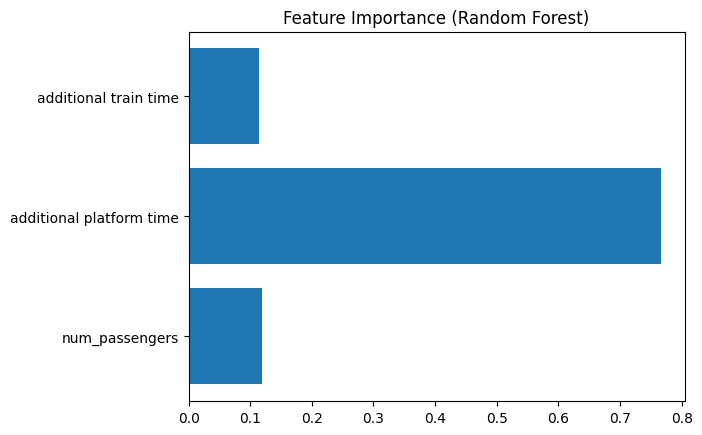

In [52]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

#Re-Runnning the Models using the Seeds

In [18]:
pip install seedhash
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from seedhash import SeedHashGenerator
import lightgbm as lgb
import xgboost as xgb
import numpy as np


# Created a generator with an input string
generator = SeedHashGenerator("MTA_STAT_ANALYSIS")

# Generated 10 random seeds
seeds = generator.generate_seeds(5)
print(seeds)

[1127031335, 306171236, 154698757, 1372642466, 1790871513]


##SEED - 1127031335

In [53]:
SEED1 = 1127031335

import numpy as np
import random
np.random.seed(SEED1)
random.seed(SEED1)

##Train-test split

In [54]:
from sklearn.model_selection import train_test_split

X = df[['num_passengers','additional platform time','additional train time']]
y = df['customer journey time performance']

# First split - 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED1
)

# Second split - 20% Validation (0.25 of remaining 80%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED1
)
# Train+Valid for final training
X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

print("Train size:", len(X_train))
print("Validation size:", len(X_valid))
print("Test size:", len(X_test))

Train size: 316
Validation size: 106
Test size: 106


In [29]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_on_test(model, X_test, y_test):
    preds = model.predict(X_test)
    return rmse(y_test, preds), r2_score(y_test, preds)

##Tuning Random Forest

In [31]:
import optuna
from sklearn.ensemble import RandomForestRegressor

def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "random_state": SEED1,
        "n_jobs": -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return rmse(y_valid, preds)

rf_study = optuna.create_study(direction="minimize")
rf_study.optimize(rf_objective, n_trials=30)

print("RF best params:", rf_study.best_params)
print("RF best valid RMSE:", rf_study.best_value)

rf_best = RandomForestRegressor(**rf_study.best_params, random_state=SEED1, n_jobs=-1)
rf_best.fit(X_train_valid, y_train_valid)

rf_test_rmse, rf_test_r2 = evaluate_on_test(rf_best, X_test, y_test)
rf_test_rmse, rf_test_r2

[I 2026-04-15 02:08:11,653] A new study created in memory with name: no-name-58ab9883-3a1d-41e7-9761-88209c3eab29
[I 2026-04-15 02:08:13,644] Trial 0 finished with value: 0.02748542763790555 and parameters: {'n_estimators': 375, 'max_depth': 29, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.02748542763790555.
[I 2026-04-15 02:08:16,287] Trial 1 finished with value: 0.027568705272643663 and parameters: {'n_estimators': 778, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.02748542763790555.
[I 2026-04-15 02:08:18,660] Trial 2 finished with value: 0.02489525721454385 and parameters: {'n_estimators': 652, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 1.0}. Best is trial 2 with value: 0.02489525721454385.
[I 2026-04-15 02:08:19,461] Trial 3 finished with value: 0.027487277151665247 and parameters: {'n_estimators': 412, 'max_depth':

RF best params: {'n_estimators': 520, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0}
RF best valid RMSE: 0.023850537872275774


(np.float64(0.02320689727004032), 0.8108465533392236)

##Tuning LightGBM

In [43]:
import lightgbm as lgb

def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": SEED1,
        "verbosity": -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return rmse(y_valid, preds)

lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=30)

print("LGBM best params:", lgb_study.best_params)
print("LGBM best valid RMSE:", lgb_study.best_value)

lgb_best = lgb.LGBMRegressor(**lgb_study.best_params, random_state=SEED1, verbosity=-1)
lgb_best.fit(X_train_valid, y_train_valid)

lgb_test_rmse, lgb_test_r2 = evaluate_on_test(lgb_best, X_test, y_test)
lgb_test_rmse, lgb_test_r2
lgb.LGBMRegressor(verbosity=-1)

[I 2026-04-15 02:16:23,894] A new study created in memory with name: no-name-b0edef37-3a02-4e92-9e01-28f00f21c960
[I 2026-04-15 02:16:24,194] Trial 0 finished with value: 0.027600294438393326 and parameters: {'n_estimators': 564, 'learning_rate': 0.015132099045874118, 'max_depth': 17, 'num_leaves': 204, 'min_child_samples': 38, 'subsample': 0.619054066300962, 'colsample_bytree': 0.6785908921595085}. Best is trial 0 with value: 0.027600294438393326.
[I 2026-04-15 02:16:24,598] Trial 1 finished with value: 0.02753917522835951 and parameters: {'n_estimators': 978, 'learning_rate': 0.011960474710807823, 'max_depth': 20, 'num_leaves': 133, 'min_child_samples': 32, 'subsample': 0.7934334351905422, 'colsample_bytree': 0.7665405258646929}. Best is trial 1 with value: 0.02753917522835951.
[I 2026-04-15 02:16:24,825] Trial 2 finished with value: 0.02862501245296003 and parameters: {'n_estimators': 647, 'learning_rate': 0.0378678354773175, 'max_depth': 19, 'num_leaves': 23, 'min_child_samples': 4

LGBM best params: {'n_estimators': 533, 'learning_rate': 0.017669621758909976, 'max_depth': 16, 'num_leaves': 216, 'min_child_samples': 13, 'subsample': 0.6319801903438993, 'colsample_bytree': 0.9154047949233921}
LGBM best valid RMSE: 0.025590378693745416


LGBMRegressor(verbosity=-1)

##Tuning XGBoost

In [33]:
import xgboost as xgb

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "random_state": SEED1,
        "objective": "reg:squarederror",
        "n_jobs": -1
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return rmse(y_valid, preds)

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=30)

print("XGB best params:", xgb_study.best_params)
print("XGB best valid RMSE:", xgb_study.best_value)

xgb_best = xgb.XGBRegressor(**xgb_study.best_params, random_state=SEED1, objective="reg:squarederror", n_jobs=-1)
xgb_best.fit(X_train_valid, y_train_valid)

xgb_test_rmse, xgb_test_r2 = evaluate_on_test(xgb_best, X_test, y_test)
xgb_test_rmse, xgb_test_r2


[I 2026-04-15 02:08:53,858] A new study created in memory with name: no-name-86d66d94-2514-4d13-b6e1-2215409c1503
[I 2026-04-15 02:08:53,951] Trial 0 finished with value: 0.03214154034065018 and parameters: {'n_estimators': 470, 'learning_rate': 0.05477957355119921, 'max_depth': 10, 'subsample': 0.6730174348087629, 'colsample_bytree': 0.7352002250267929, 'reg_alpha': 1.102956192047072, 'reg_lambda': 0.8295603420861615}. Best is trial 0 with value: 0.03214154034065018.
[I 2026-04-15 02:08:54,083] Trial 1 finished with value: 0.02537202259508585 and parameters: {'n_estimators': 265, 'learning_rate': 0.13494295744456467, 'max_depth': 8, 'subsample': 0.7663506373574156, 'colsample_bytree': 0.6726687420929335, 'reg_alpha': 0.04812876456418902, 'reg_lambda': 0.1764009053351152}. Best is trial 1 with value: 0.02537202259508585.
[I 2026-04-15 02:08:54,243] Trial 2 finished with value: 0.03399944556074774 and parameters: {'n_estimators': 1172, 'learning_rate': 0.040377765922973166, 'max_depth':

XGB best params: {'n_estimators': 558, 'learning_rate': 0.1931235395755107, 'max_depth': 3, 'subsample': 0.7913047884822312, 'colsample_bytree': 0.843149569955575, 'reg_alpha': 0.13978041795918317, 'reg_lambda': 1.622447642808827}
XGB best valid RMSE: 0.02487054510748442


(np.float64(0.022855376256407867), 0.8165334686587435)

In [34]:
seeds_list = [
    1127031335,
    306171236,
    154698757,
    1372642466,
    1790871513
]

all_results = []

In [62]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb


def run_pipeline(SEED):

    # Split
    X = df[['num_passengers','additional platform time','additional train time']]
    y = df['customer journey time performance']

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=SEED
    )

    X_train_valid = pd.concat([X_train, X_valid])
    y_train_valid = pd.concat([y_train, y_valid])

    # RANDOM FOREST
    def rf_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800),
            "max_depth": trial.suggest_int("max_depth", 3, 25),
            "random_state": SEED,
            "n_jobs": -1
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        return np.sqrt(mean_squared_error(y_valid, preds))

    rf_study = optuna.create_study(direction="minimize")
    rf_study.optimize(rf_objective, n_trials=20, show_progress_bar=False)

    rf_model = RandomForestRegressor(**rf_study.best_params, random_state=SEED, n_jobs=-1)
    rf_model.fit(X_train_valid, y_train_valid)
    rf_preds = rf_model.predict(X_test)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
    rf_r2 = r2_score(y_test, rf_preds)

    # LIGHTGBM
    def lgb_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "random_state": SEED,
            "verbosity": -1
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        return np.sqrt(mean_squared_error(y_valid, preds))

    lgb_study = optuna.create_study(direction="minimize")
    lgb_study.optimize(lgb_objective, n_trials=20, show_progress_bar=False)

    lgb_model = lgb.LGBMRegressor(**lgb_study.best_params, random_state=SEED, verbosity=-1)
    lgb_model.fit(X_train_valid, y_train_valid)
    lgb_preds = lgb_model.predict(X_test)
    lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
    lgb_r2 = r2_score(y_test, lgb_preds)

    # XGBOOST
    def xgb_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "random_state": SEED,
            "objective": "reg:squarederror",
            "n_jobs": -1
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        return np.sqrt(mean_squared_error(y_valid, preds))

    xgb_study = optuna.create_study(direction="minimize")
    xgb_study.optimize(xgb_objective, n_trials=20, show_progress_bar=False)

    xgb_model = xgb.XGBRegressor(**xgb_study.best_params, random_state=SEED, objective="reg:squarederror", n_jobs=-1)
    xgb_model.fit(X_train_valid, y_train_valid)
    xgb_preds = xgb_model.predict(X_test)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
    xgb_r2 = r2_score(y_test, xgb_preds)

    return {
        "Seed": SEED,
        "RF_RMSE": rf_rmse,
        "RF_R2": rf_r2,
        "LGBM_RMSE": lgb_rmse,
        "LGBM_R2": lgb_r2,
        "XGB_RMSE": xgb_rmse,
        "XGB_R2": xgb_r2
    }

In [63]:
for s in seeds_list:
    print(f"Running seed {s}...")
    result = run_pipeline(s)
    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df

[I 2026-04-15 02:26:27,332] A new study created in memory with name: no-name-24271467-1350-4e71-87d3-5fec5918a392


Running seed 1127031335...


[I 2026-04-15 02:26:28,337] Trial 0 finished with value: 0.025374598107254998 and parameters: {'n_estimators': 477, 'max_depth': 4}. Best is trial 0 with value: 0.025374598107254998.
[I 2026-04-15 02:26:29,651] Trial 1 finished with value: 0.023962472867459776 and parameters: {'n_estimators': 562, 'max_depth': 21}. Best is trial 1 with value: 0.023962472867459776.
[I 2026-04-15 02:26:31,924] Trial 2 finished with value: 0.02402432911512099 and parameters: {'n_estimators': 736, 'max_depth': 10}. Best is trial 1 with value: 0.023962472867459776.
[I 2026-04-15 02:26:33,750] Trial 3 finished with value: 0.023959834634879787 and parameters: {'n_estimators': 528, 'max_depth': 24}. Best is trial 3 with value: 0.023959834634879787.
[I 2026-04-15 02:26:35,462] Trial 4 finished with value: 0.023985168279420026 and parameters: {'n_estimators': 733, 'max_depth': 15}. Best is trial 3 with value: 0.023959834634879787.
[I 2026-04-15 02:26:36,915] Trial 5 finished with value: 0.023913580743921026 and 

Running seed 306171236...


[I 2026-04-15 02:27:10,139] Trial 0 finished with value: 0.024292249723064832 and parameters: {'n_estimators': 649, 'max_depth': 18}. Best is trial 0 with value: 0.024292249723064832.
[I 2026-04-15 02:27:11,979] Trial 1 finished with value: 0.02387441403467045 and parameters: {'n_estimators': 541, 'max_depth': 7}. Best is trial 1 with value: 0.02387441403467045.
[I 2026-04-15 02:27:13,505] Trial 2 finished with value: 0.024317160342730085 and parameters: {'n_estimators': 586, 'max_depth': 23}. Best is trial 1 with value: 0.02387441403467045.
[I 2026-04-15 02:27:14,626] Trial 3 finished with value: 0.024248686468409688 and parameters: {'n_estimators': 477, 'max_depth': 12}. Best is trial 1 with value: 0.02387441403467045.
[I 2026-04-15 02:27:16,428] Trial 4 finished with value: 0.024228378605665842 and parameters: {'n_estimators': 792, 'max_depth': 12}. Best is trial 1 with value: 0.02387441403467045.
[I 2026-04-15 02:27:17,871] Trial 5 finished with value: 0.02427595910971762 and param

...

Running seed 1372642466...


[I 2026-04-15 02:28:14,010] Trial 0 finished with value: 0.022020201539243705 and parameters: {'n_estimators': 721, 'max_depth': 18}. Best is trial 0 with value: 0.022020201539243705.
[I 2026-04-15 02:28:16,432] Trial 1 finished with value: 0.022050306739845153 and parameters: {'n_estimators': 763, 'max_depth': 12}. Best is trial 0 with value: 0.022020201539243705.
[I 2026-04-15 02:28:18,603] Trial 2 finished with value: 0.022087590319791583 and parameters: {'n_estimators': 747, 'max_depth': 11}. Best is trial 0 with value: 0.022020201539243705.
[I 2026-04-15 02:28:19,783] Trial 3 finished with value: 0.021999798600606912 and parameters: {'n_estimators': 508, 'max_depth': 19}. Best is trial 3 with value: 0.021999798600606912.
[I 2026-04-15 02:28:20,410] Trial 4 finished with value: 0.02201655711184789 and parameters: {'n_estimators': 270, 'max_depth': 19}. Best is trial 3 with value: 0.021999798600606912.
[I 2026-04-15 02:28:21,778] Trial 5 finished with value: 0.02198450483743084 and 

Running seed 1790871513...


[I 2026-04-15 02:28:49,072] Trial 0 finished with value: 0.023315239559727176 and parameters: {'n_estimators': 503, 'max_depth': 8}. Best is trial 0 with value: 0.023315239559727176.
[I 2026-04-15 02:28:49,861] Trial 1 finished with value: 0.023547267695580517 and parameters: {'n_estimators': 344, 'max_depth': 24}. Best is trial 0 with value: 0.023315239559727176.
[I 2026-04-15 02:28:50,881] Trial 2 finished with value: 0.023507316575056295 and parameters: {'n_estimators': 435, 'max_depth': 21}. Best is trial 0 with value: 0.023315239559727176.
[I 2026-04-15 02:28:51,995] Trial 3 finished with value: 0.023915826220103183 and parameters: {'n_estimators': 558, 'max_depth': 4}. Best is trial 0 with value: 0.023315239559727176.
[I 2026-04-15 02:28:52,812] Trial 4 finished with value: 0.023674769170953434 and parameters: {'n_estimators': 350, 'max_depth': 12}. Best is trial 0 with value: 0.023315239559727176.
[I 2026-04-15 02:28:53,832] Trial 5 finished with value: 0.023397274072970032 and 

,Seed,RF_RMSE,RF_R2,LGBM_RMSE,LGBM_R2,XGB_RMSE,XGB_R2
0,1127031335,0.023259,0.809996,0.022536,0.821632,0.026551,0.752404
1,306171236,0.024427,0.784224,0.023984,0.791985,0.026040,0.754792
2,154698757,0.027035,0.772427,0.026478,0.781707,0.029038,0.737467
3,1372642466,0.023461,0.776772,0.022921,0.786929,0.023398,0.777956
4,1790871513,0.026340,0.761236,0.024969,0.785446,0.025445,0.777184
5,1127031335,0.023194,0.811049,0.022753,0.818173,0.026572,0.752016
6,306171236,0.024406,0.784603,0.024376,0.785126,0.025944,0.756603
7,154698757,0.026875,0.775113,0.026324,0.784242,0.029170,0.735063
8,1372642466,0.023447,0.777025,0.023232,0.781106,0.023080,0.783952
9,1790871513,0.026298,0.761995,0.025313,0.779483,0.026819,0.752474


In [37]:
print("Mean Performance Across Seeds:")
display(results_df.mean())

print("Standard Deviation Across Seeds:")
display(results_df.std())

Mean Performance Across Seeds:


,0
Seed,9.502831e+08
RF_RMSE,2.490432e-02
RF_R2,7.809314e-01
LGBM_RMSE,2.417741e-02
LGBM_R2,7.935395e-01
XGB_RMSE,2.609435e-02
XGB_R2,7.599605e-01


Standard Deviation Across Seeds:


,0
Seed,7.007230e+08
RF_RMSE,1.704386e-03
RF_R2,1.825594e-02
LGBM_RMSE,1.599405e-03
LGBM_R2,1.613098e-02
XGB_RMSE,2.035011e-03
XGB_R2,1.739450e-02


In [38]:
# Final test results from models
results = {
    "Model": ["Random Forest", "LightGBM", "XGBoost"],
    "RMSE": [rf_test_rmse, lgb_test_rmse, xgb_test_rmse],
    "R2": [rf_test_r2, lgb_test_r2, xgb_test_r2]
}

results_df = pd.DataFrame(results)

# Sort by RMSE (lower is better)
results_df = results_df.sort_values(by="RMSE")

print(results_df)

           Model      RMSE        R2
2        XGBoost  0.022855  0.816533
0  Random Forest  0.023207  0.810847
1       LightGBM  0.024113  0.795788


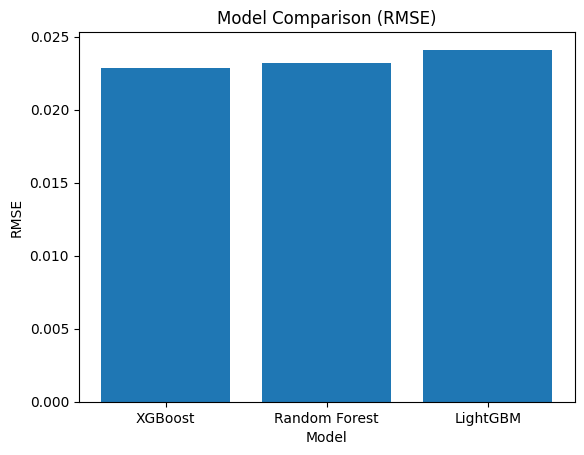

In [39]:
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

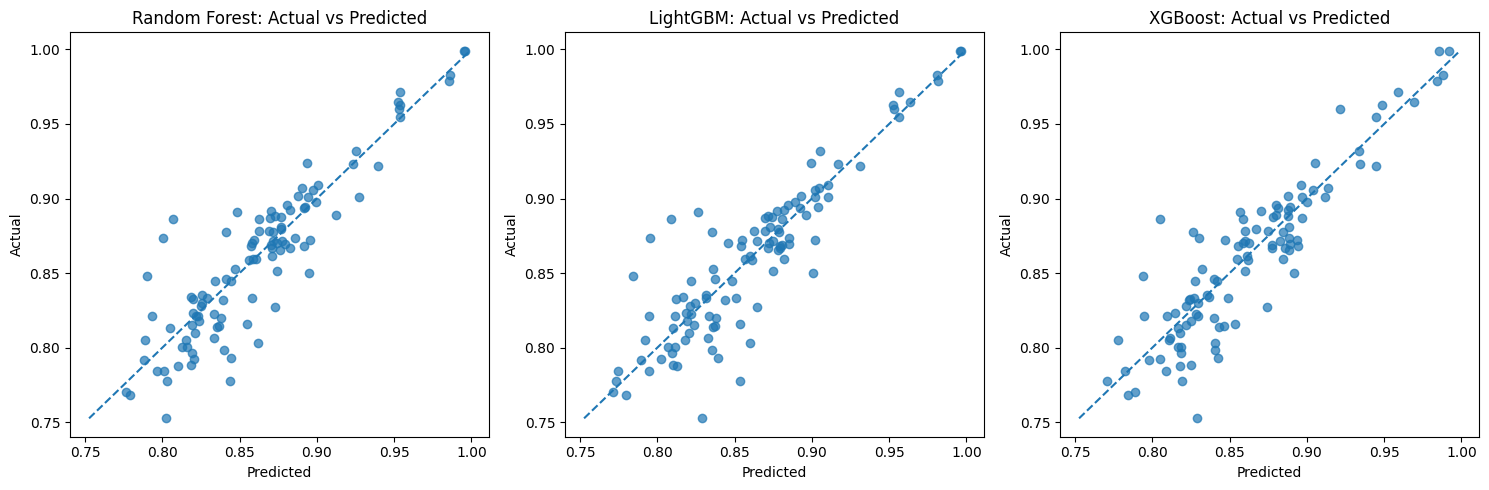

In [40]:
# Generate predictions on test set

rf_pred = rf_best.predict(X_test)
lgb_pred = lgb_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

import matplotlib.pyplot as plt
import numpy as np

# Predictions
# y_test, rf_pred, lgb_pred, xgb_pred

models = {
    "Random Forest": rf_pred,
    "LightGBM": lgb_pred,
    "XGBoost": xgb_pred
}

plt.figure(figsize=(15,5))

for i, (name, preds) in enumerate(models.items()):
    plt.subplot(1,3,i+1)

    # Scatter plot
    plt.scatter(preds, y_test, alpha=0.7)

    # Reference line (Perfect prediction line)
    min_val = min(min(preds), min(y_test))
    max_val = max(max(preds), max(y_test))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    plt.title(f"{name}: Actual vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

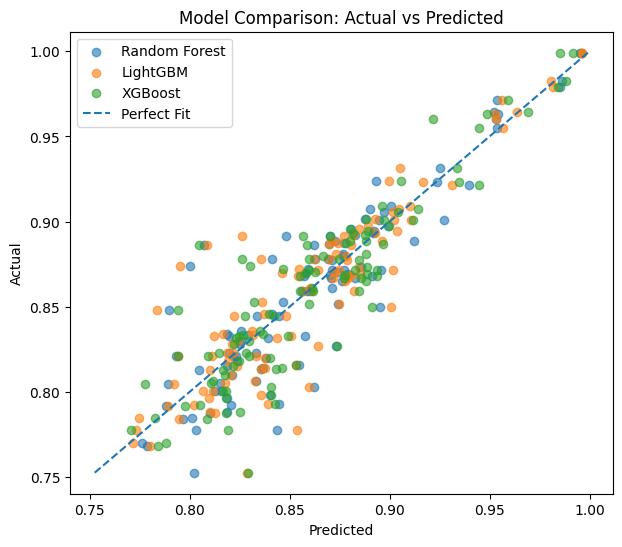

In [41]:
plt.figure(figsize=(7,6))

plt.scatter(rf_pred, y_test, alpha=0.6, label="Random Forest")
plt.scatter(lgb_pred, y_test, alpha=0.6, label="LightGBM")
plt.scatter(xgb_pred, y_test, alpha=0.6, label="XGBoost")

# Perfect prediction line
min_val = min(y_test)
max_val = max(y_test)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label="Perfect Fit")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model Comparison: Actual vs Predicted")
plt.legend()

plt.show()

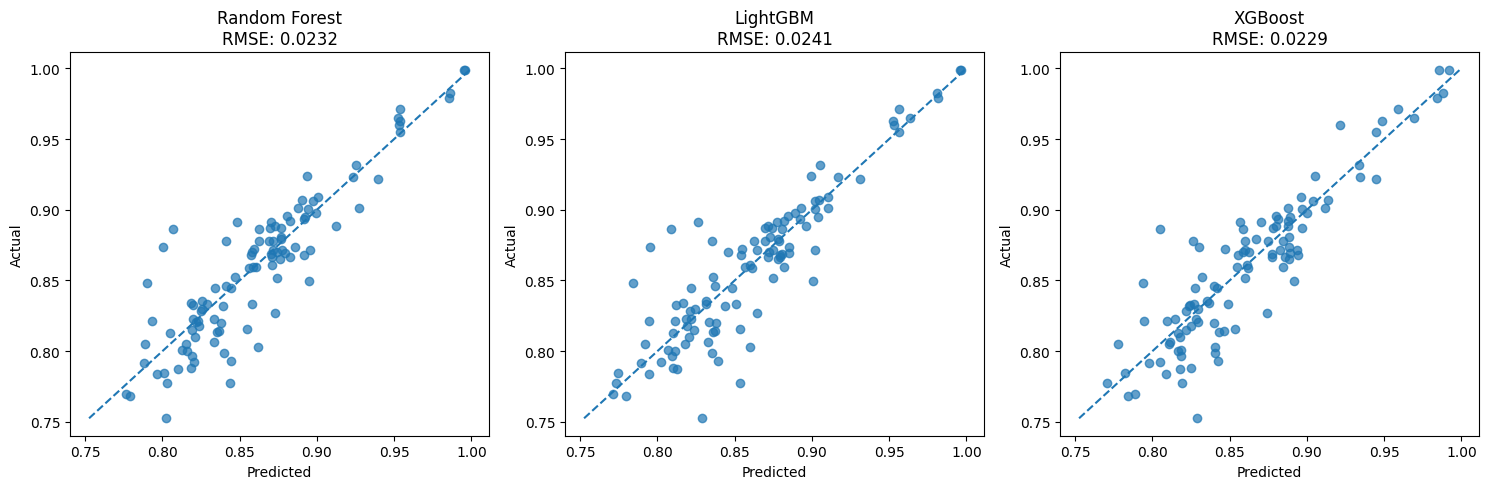

In [42]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

plt.figure(figsize=(15,5))

for i, (name, preds) in enumerate(models.items()):
    plt.subplot(1,3,i+1)

    plt.scatter(preds, y_test, alpha=0.7)

    min_val = min(min(preds), min(y_test))
    max_val = max(max(preds), max(y_test))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    score = rmse(y_test, preds)

    plt.title(f"{name}\nRMSE: {score:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()